# 딥러닝 기초 3일차 실습과제: 정규화와 일반화

## 과제 개요
이 과제에서는 **과적합(Overfitting)**을 방지하기 위한 다양한 **정규화 기법**을 적용하고 비교합니다.

### 사용 데이터셋
- **Pima Indians Diabetes Database** (2일차와 동일)

### 학습 목표
1. 과적합의 원인과 현상 이해
2. Dropout 적용 및 효과 확인
3. Weight Decay (L2 정규화) 적용
4. Batch Normalization 이해
5. 정규화 기법 조합 및 최적 모델 선택

### 예상 소요 시간
약 **1시간 30분**

---

## Part 0: 환경 설정 및 데이터 준비

In [1]:
# 필요한 라이브러리 import
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns

# 재현성
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [2]:
# 데이터 로드 및 전처리
df = pd.read_csv('diabetes.csv')

X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

# Train/Val/Test 분할 (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# 정규화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Tensor 변환
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
X_val_t = torch.FloatTensor(X_val_scaled)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
X_test_t = torch.FloatTensor(X_test_scaled)
y_test_t = torch.FloatTensor(y_test).unsqueeze(1)

# DataLoader
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 460, Val: 154, Test: 154


---

## Part 1: 과적합 현상 관찰

먼저 정규화 없이 모델을 학습하여 과적합 현상을 관찰합니다.

In [3]:
# ============================================
# 학습/평가 함수 (Early Stopping 포함)
# ============================================

def train_model(model, train_loader, val_loader, criterion, optimizer, 
                num_epochs=100, patience=15, device='cpu'):
    """
    모델 학습 함수 (Early Stopping 포함)
    """
    model = model.to(device)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            train_correct += ((outputs > 0.5).float() == y_batch).sum().item()
            train_total += y_batch.size(0)
        
        # Validate
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                val_correct += ((outputs > 0.5).float() == y_batch).sum().item()
                val_total += y_batch.size(0)
        
        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['train_acc'].append(train_correct / train_total)
        history['val_acc'].append(val_correct / val_total)
        
        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Train: {history['train_loss'][-1]:.4f}/{history['train_acc'][-1]:.4f} "
                  f"Val: {history['val_loss'][-1]:.4f}/{history['val_acc'][-1]:.4f}")
    
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    return model, history


def evaluate_model(model, test_loader, device='cpu'):
    """모델 평가"""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = (outputs > 0.5).float().cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(y_batch.numpy())
    
    all_preds = np.array(all_preds).flatten()
    all_labels = np.array(all_labels).flatten()
    
    return {
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1': f1_score(all_labels, all_preds)
    }


def plot_history(history, title):
    """학습 곡선 시각화"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(history['train_loss'], label='Train', color='#8FBC8F')
    axes[0].plot(history['val_loss'], label='Val', color='#87CEEB')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history['train_acc'], label='Train', color='#8FBC8F')
    axes[1].plot(history['val_acc'], label='Val', color='#87CEEB')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

Baseline 모델 (정규화 없음)
Epoch [20/100] Train: 0.3597/0.8435 Val: 0.4496/0.7792
Early stopping at epoch 29

Test Accuracy: 0.7338, F1: 0.6239


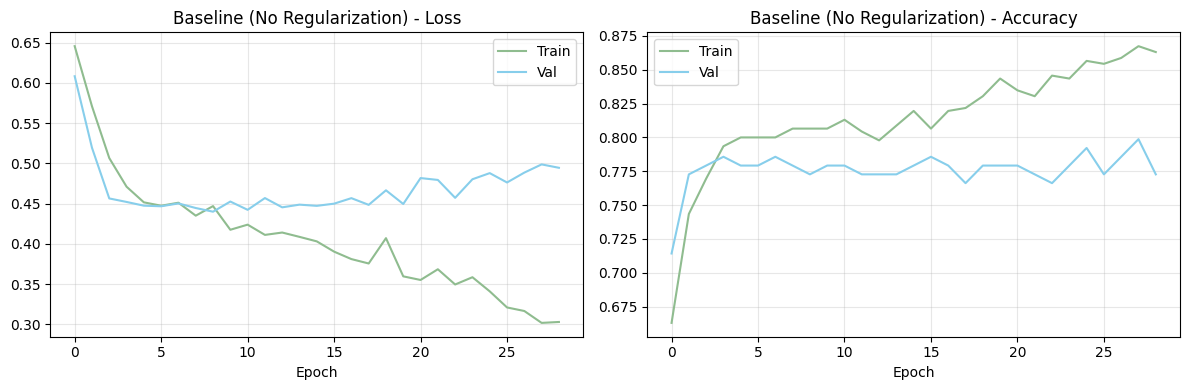

In [4]:
# 정규화 없는 기본 모델
class BaselineMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(8, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

print("=" * 50)
print("Baseline 모델 (정규화 없음)")
print("=" * 50)

baseline = BaselineMLP()
optimizer = optim.Adam(baseline.parameters(), lr=0.001)
criterion = nn.BCELoss()

baseline, baseline_history = train_model(
    baseline, train_loader, val_loader, criterion, optimizer,
    num_epochs=100, patience=20, device=device
)

baseline_metrics = evaluate_model(baseline, test_loader, device)
print(f"\nTest Accuracy: {baseline_metrics['accuracy']:.4f}, F1: {baseline_metrics['f1']:.4f}")

plot_history(baseline_history, "Baseline (No Regularization)")

---

## Part 2: 정규화 기법 비교

Dropout, Weight Decay, Batch Normalization을 적용하고 비교합니다.

In [5]:
# ============================================
# 정규화 적용 모델
# ============================================

class RegularizedMLP(nn.Module):
    def __init__(self, dropout_rate=0.0, use_batchnorm=False):
        super().__init__()
        
        layers = []
        
        # Layer 1
        layers.append(nn.Linear(8, 128))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(128))
        layers.append(nn.ReLU())
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        
        # Layer 2
        layers.append(nn.Linear(128, 64))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(64))
        layers.append(nn.ReLU())
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        
        # Layer 3
        layers.append(nn.Linear(64, 32))
        if use_batchnorm:
            layers.append(nn.BatchNorm1d(32))
        layers.append(nn.ReLU())
        if dropout_rate > 0:
            layers.append(nn.Dropout(dropout_rate))
        
        # Output
        layers.append(nn.Linear(32, 1))
        layers.append(nn.Sigmoid())
        
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)

In [12]:
# 정규화 기법 비교 실험
configs = {
    'Baseline': {'dropout': 0.0, 'batchnorm': False, 'weight_decay': 0},
    'Dropout 0.3': {'dropout': 0.3, 'batchnorm': False, 'weight_decay': 0},
    'Weight Decay': {'dropout': 0.0, 'batchnorm': False, 'weight_decay': 0.01},
    'BatchNorm': {'dropout': 0.0, 'batchnorm': True, 'weight_decay': 0},
    'All Combined': {'dropout': 0.3, 'batchnorm': True, 'weight_decay': 0.001},
    'batch+dropout':{'dropout': 0.3, 'batchnorm': True, 'weight_decay': 0},
}

results = {}

for name, cfg in configs.items():
    print(f"\n{'='*40}")
    print(f"{name}")
    print("="*40)
    
    model = RegularizedMLP(dropout_rate=cfg['dropout'], use_batchnorm=cfg['batchnorm'])
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=cfg['weight_decay'])
    criterion = nn.BCELoss()
    
    model, history = train_model(
        model, train_loader, val_loader, criterion, optimizer,
        num_epochs=100, patience=15, device=device
    )
    
    metrics = evaluate_model(model, test_loader, device)
    results[name] = {'history': history, 'metrics': metrics}
    
    print(f"Test Acc: {metrics['accuracy']:.4f}, F1: {metrics['f1']:.4f}")


Baseline
Epoch [20/100] Train: 0.3783/0.8326 Val: 0.4470/0.7403
Early stopping at epoch 23
Test Acc: 0.7338, F1: 0.6095

Dropout 0.3
Epoch [20/100] Train: 0.4443/0.8000 Val: 0.4359/0.7922
Epoch [40/100] Train: 0.4202/0.8087 Val: 0.4310/0.7662
Early stopping at epoch 41
Test Acc: 0.7208, F1: 0.5905

Weight Decay
Epoch [20/100] Train: 0.4469/0.8000 Val: 0.4355/0.7727
Epoch [40/100] Train: 0.4208/0.8217 Val: 0.4398/0.7857
Early stopping at epoch 45
Test Acc: 0.7532, F1: 0.6346

BatchNorm
Epoch [20/100] Train: 0.3012/0.8739 Val: 0.5229/0.8052
Early stopping at epoch 23
Test Acc: 0.7468, F1: 0.6355

All Combined
Epoch [20/100] Train: 0.5006/0.7587 Val: 0.4295/0.7792
Early stopping at epoch 34
Test Acc: 0.7273, F1: 0.5882

batch+dropout
Epoch [20/100] Train: 0.4420/0.7957 Val: 0.4367/0.7792
Epoch [40/100] Train: 0.4481/0.7848 Val: 0.4490/0.7727
Early stopping at epoch 47
Test Acc: 0.7403, F1: 0.6226


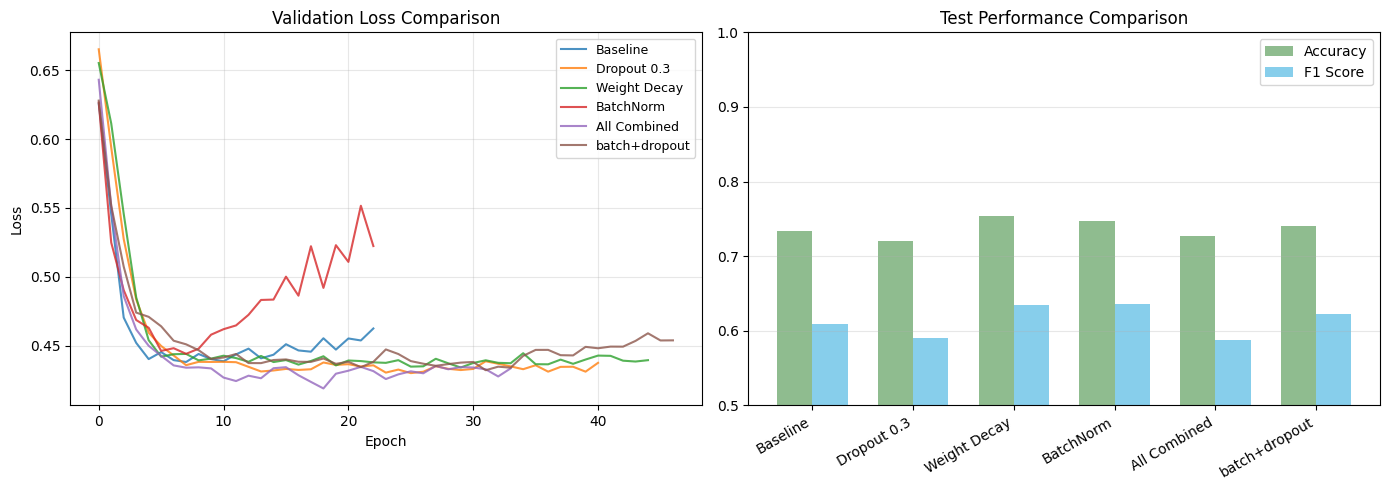


정규화 기법 성능 비교
기법                 |   Accuracy |   F1 Score
--------------------------------------------------
Baseline           |     0.7338 |     0.6095
Dropout 0.3        |     0.7208 |     0.5905
Weight Decay       |     0.7532 |     0.6346
BatchNorm          |     0.7468 |     0.6355
All Combined       |     0.7273 |     0.5882
batch+dropout      |     0.7403 |     0.6226


In [13]:
# 결과 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation Loss 비교
for name, result in results.items():
    axes[0].plot(result['history']['val_loss'], label=name, alpha=0.8)
axes[0].set_title('Validation Loss Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# 성능 비교 바 차트
names = list(results.keys())
accs = [results[n]['metrics']['accuracy'] for n in names]
f1s = [results[n]['metrics']['f1'] for n in names]

x = np.arange(len(names))
width = 0.35

axes[1].bar(x - width/2, accs, width, label='Accuracy', color='#8FBC8F')
axes[1].bar(x + width/2, f1s, width, label='F1 Score', color='#87CEEB')
axes[1].set_title('Test Performance Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=30, ha='right')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 결과 표
print("\n" + "=" * 50)
print("정규화 기법 성능 비교")
print("=" * 50)
print(f"{'기법':<18} | {'Accuracy':>10} | {'F1 Score':>10}")
print("-" * 50)
for name, result in results.items():
    m = result['metrics']
    print(f"{name:<18} | {m['accuracy']:>10.4f} | {m['f1']:>10.4f}")

### [필수] 과제 2-1: 정규화 기법 분석

위 실험 결과를 보고 답하세요:

1. 어떤 정규화 기법이 가장 좋은 성능을 보였나요?
   - 답변: batchnorm / 실험을 다시 돌려보니 변동이 큼. dataset이 너무 작아서 그런게 아닐가 예상됨.

2. Dropout이 과적합 방지에 어떻게 도움이 되나요? (학습 곡선 참고)
   - 답변: 학습 중 일부 뉴런을 랜덤하게 비활성하여 특정 뉴런이나 특정 패턴에 과하게 의존하는 것을 막아줌. 그래프에서도 dropout모델은 validationloss가 비교적 낮음.

---

## Part 3: 최종 모델 평가

최고 성능 모델: All Combined
Epoch [20/100] Train: 0.4351/0.8065 Val: 0.4350/0.7662
Epoch [40/100] Train: 0.4389/0.7935 Val: 0.4337/0.7727
Early stopping at epoch 49


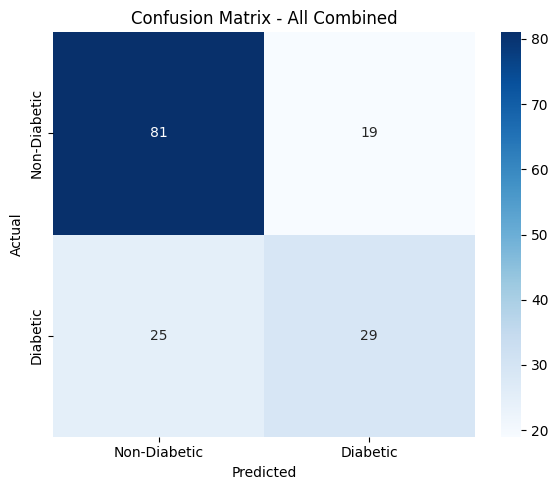


최종 성능: Accuracy=0.7143, F1=0.5686


In [13]:
# 최고 성능 모델 선택 및 상세 평가
best_name = max(results.items(), key=lambda x: x[1]['metrics']['f1'])[0]
print(f"최고 성능 모델: {best_name}")

# 최종 모델 다시 학습
best_cfg = configs[best_name]
final_model = RegularizedMLP(
    dropout_rate=best_cfg['dropout'], 
    use_batchnorm=best_cfg['batchnorm']
)
optimizer = optim.Adam(final_model.parameters(), lr=0.001, weight_decay=best_cfg['weight_decay'])
criterion = nn.BCELoss()

final_model, final_history = train_model(
    final_model, train_loader, val_loader, criterion, optimizer,
    num_epochs=100, patience=20, device=device
)

# 혼동 행렬
final_model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = final_model(X_batch)
        preds = (outputs > 0.5).float().cpu()
        all_preds.extend(preds.numpy().flatten())
        all_labels.extend(y_batch.numpy().flatten())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title(f'Confusion Matrix - {best_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

final_metrics = evaluate_model(final_model, test_loader, device)
print(f"\n최종 성능: Accuracy={final_metrics['accuracy']:.4f}, F1={final_metrics['f1']:.4f}")

---

## 3일차 학습 정리 체크리스트

아래 항목을 체크하세요:

- [ ] 과적합 현상 이해: Train 손실은 감소하지만 Val 손실은 증가
- [ ] Dropout: 학습 시 랜덤하게 뉴런을 비활성화
- [ ] Weight Decay (L2): 가중치가 너무 커지는 것을 방지
- [ ] Batch Normalization: 각 층의 입력을 정규화하여 학습 안정화
- [ ] Early Stopping: 검증 손실이 개선되지 않으면 학습 조기 종료

---

## 수고하셨습니다!

### 제출 전 체크리스트
- [ ] 과제 2-1 (정규화 기법 분석) 답변 작성
- [ ] 모든 셀 실행 완료